In [1]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))

def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, phi is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    theta is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(theta) * np.cos(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(theta)]

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
    
    return efficiency

def eta_sat(L, h, r, R, eff):
    
    lam = 810e-9;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eff;
    
    return efficiency

def generate_sat_ring(num_sats, R, h, theta, phi, offset, multiple_alt=False):
    # Last modified: 3 October 2019

    """
    Generates the satellite architecture consisting of n rings at azimuthal
    angles 'phi'(in degrees) and polar angles 'theta'(in degrees) stored in lists of length
    n each.  There are num_sats equally-spaced satellites in each ring.  R is
    the radius of the earth (in meters), and h is the altitude of the
    satellites (in meters)
  Parameters
  ----------
  num_sats:
      number of satellites in each ring
  R:
      Repition rate of the source in ebits / sec
  h:
      altitude for the satellite rings (in meters), If multiple_alt = True, then h should be a list of altitudes.
  phi:
      list of azimuthal angles (longitudes in degrees) at which the polar rings are set up.
  theta:
      list of angles (in degrees) through which the polar rings are rotated about the x-axis (latitude rotation)
      to make them tilted.
  offset:
      list of initial offset polar angles (latitudes in degrees) at which the rings are set up.
  Returns
  -------
  S:
      dictionary containing positions of the satellites and their orbit axes.
  """
    S = {}
    for i in range(len(theta)):
        theta[i] = theta[i] * np.pi / 180
        offset[i] = offset[i] * np.pi / 180
        
        phi[i] = phi[i] * np.pi / 180
        S[i] = {}
        count1 = 0
        
        for k in range(0, num_sats):
            count1 += 1
            S[i][count1] = generate_point(R + h, 2 * k * np.pi / num_sats + offset[i], np.pi/2-phi[i])
            rot_pt = generate_rotation([1, 0, 0], np.pi/2-theta[i]) * np.matrix(S[i][count1]).H
            S[i][count1] = [np.array(rot_pt[0])[0][0], np.array(rot_pt[1])[0][0], np.array(rot_pt[2])[0][0]]

        S[i]['axis'] = [np.sin(theta[i]) * np.cos(phi[i]), np.sin(theta[i]) * np.sin(phi[i]), np.cos(theta[i])]

    return S

#constants

c = 2.9978e8
R = 6371e3
h = 500e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600

# protocol run parameters

noise_rate_gs = 1e5
noise_rate_sat = 1e5
pair_rate = 1e7
dt = 1e-9
N_c = 10

T_big = math.floor(86400/100)
dT = 1
bigsteps = math.floor(T_big/dT)


#ground stations

G = {}

# generating ground stations

axis_earth = np.array([0,0,1]) #z-axis

G[1] = generate_point(R, 74.0060 * np.pi / 180, (90 - 40.7128) * np.pi / 180)   # NYC
G[2] = generate_point(R, 118.2437 * np.pi / 180, (90 - 34.0522) * np.pi / 180)  # LA
#G[2][1] = generate_point(R, -0.1278 * np.pi / 180, (90 - 51.5074) * np.pi / 180)  # LON
G[3] = generate_point(R, 122.3321 * np.pi / 180, (90 - 47.6062) * np.pi / 180)  # SEA
G[4] = generate_point(R, 84.3880 * np.pi / 180, (90 - 33.7490) * np.pi / 180)   # ATL

'''
G[1] = generate_point(R, 74.0060 * np.pi / 180, (90 - 40.7128) * np.pi / 180)   # NYC
G[2] = generate_point(R, -0.1278 * np.pi / 180, (90 - 51.5074) * np.pi / 180)  # LON
G[3] = generate_point(R, 151.2093 * np.pi / 180, (90 + 33.8688) * np.pi / 180)   # SYD
G[4] = generate_point(R, 18.4241 * np.pi / 180, (90 + 33.9249) * np.pi / 180)   # CAP
'''

#satellite constellation
n_sat = 10
# orientation angles for rings of satellites
theta = [90]
offset = [0]
phi = [90]


# generating the satellite constellation
S = generate_sat_ring(n_sat, R, h, theta, phi, offset, multiple_alt=False)

def sat_dynamics(t):
    t_gb = t
    Data = {}


    if t_gb%1e3 == 0:
        print(t_gb)
    
    for i in list(G.keys()):
        G[i] = evolve_vector(G[i], axis_earth, Om, t_gb*dT)
        
        Data[i] = {}
    
        for j in list(S.keys()):
            ring_axis = np.array(S[j]['axis'])
            if j =='axis':
                continue 
        
            for k in list(S[j].keys()):
                if k =='axis':
                    continue
                sat_label = str([j,k])

                S[j][k] = evolve_vector(S[j][k], ring_axis, om, t_gb*dT)

                ang = np.dot(np.subtract(S[j][k],G[i]),G[i])/np.linalg.norm(G[i])/np.linalg.norm(np.subtract(S[j][k],G[i]))
                if ang > 1e-10:
                    v_gs = np.cross(G[i], Om*axis_earth)
                    v_sat = np.cross(S[j][k], om*ring_axis)
                    v_rel_rad = np.dot(np.subtract(v_sat, v_gs), np.subtract(S[j][k], G[i])/np.linalg.norm(np.subtract(S[j][k], G[i])))
                    N = dt/abs(v_rel_rad/c)*eta(dst(G[i], S[j][k]), h, 0.6, 0.1, 0.25)*pair_rate
                    if N>N_c:
                        Data[i][sat_label] = -math.log10(dt*N_c/N)
                    else:
                        Data[i][sat_label] = 0
                else:
                    Data[i][sat_label] = 0  

    return Data

t_start = time.time()
data = Parallel(n_jobs=15)(delayed(sat_dynamics)(t) for t in range(bigsteps))
print(time.time() - t_start)

print("game over")         

26.66564130783081
game over


In [2]:
city1 = 1
city2 = 3
prec_1 = np.array([]); prec_2 = np.array([]); prec_12 = np.array([])
for t in range(bigsteps):
    max_prec1 = 0; max_prec2 = 0;
    
    for j in list(S.keys()):
        ring_axis = np.array(S[j]['axis'])
        if j =='axis':
            continue 

        for k in list(S[j].keys()):    
            if k =='axis':
                continue
            label = str([j,k])


    if data[t][city1][label] > max_prec1:
        max_prec1 = data[t][city1][label]

    if data[t][city2][label] > max_prec2:
        max_prec2 = data[t][city2][label]

    prec_1 = np.append(prec_1, max_prec1) 
    prec_2 = np.append(prec_2, max_prec2)
    prec_12 = np.append(prec_12, min(max_prec1, max_prec2))
    

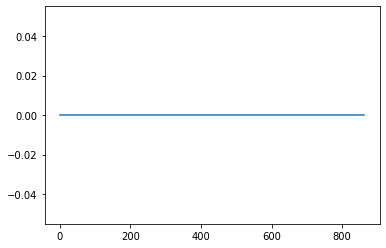

In [3]:
plt.plot([t for t in range(bigsteps)], prec_12)
#plt.plot([t for t in range(bigsteps)], prec_2)
#plt.plot([t for t in range(bigsteps)], prec_12)

In [5]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

def lineseg_dist(p, a, b):

    # normalized tangent vector
    d = np.divide(b - a, np.linalg.norm(b - a))

    # signed parallel distance components
    s = np.dot(a - p, d)
    t = np.dot(p - b, d)

    # clamped parallel distance
    h = np.maximum.reduce([s, t, 0])

    # perpendicular distance component
    c = np.cross(p - a, d)

    return np.hypot(h, np.linalg.norm(c))

#constants

c = 2.9978e8
R = 6371e3
h = 1000e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600

# protocol run parameters

noise_rate_gs = 1e5
noise_rate_sat = 1e5
pair_rate = 1e7
dt = 1e-9
N_c = 10

T_big = math.floor(86400/100)
dT = 1
bigsteps = math.floor(T_big/dT)


#satellite constellation
n_sat = 10
# orientation angles for rings of satellites
theta = [0]
offset = [0]
phi = [90]
prec = np.zeros([n_sat,n_sat])

# generating the satellite constellation
S_0 = generate_sat_ring(n_sat, R, h, theta, phi, offset, multiple_alt=False)
ring_axis = S_0[0]['axis']

print(S_0)

#dynamics
def sat_sat_links(t):
    
    for j in range(1,n_sat+1):
        S[0][j] = evolve_vector(S_0[0][j], ring_axis, om, t*dT)
    
    for j in range(1,n_sat+1):
        for k in range(1,n_sat+1):
            if k != j:
                p_dist = lineseg_dist(np.array([0,0,0]), np.array(S[0][j]), np.array(S[0][k])) - R  

                if p_dist > 1e-10:
                    v_sat1 = np.cross(np.array(S[0][j]), om*np.array(ring_axis))
                    v_sat2 = np.cross(np.array(S[0][k]), om*np.array(ring_axis))
                    v_rel_rad = np.dot(np.subtract(v_sat1, v_sat2), np.subtract(S[0][k],S[0][j])/np.linalg.norm(np.subtract(S[0][k],S[0][j])))
                    N = dt/abs(v_rel_rad/c)*eta_sat(dst(S[0][j], S[0][k]), h, 0.1, 0.1, 0.25)*pair_rate
                    if N > 0:
                        prec[j-1][k-1] = -math.log10(dt*N_c/N)
                    else:
                        prec[j-1][k-1] = 0
                else:
                    prec[j-1][k-1] = 0
            else:
                prec[j-1][k-1] = 0
    
    return prec  
    
data = Parallel(n_jobs=15)(delayed(sat_sat_links)(t) for t in range(bigsteps))
print('game over')

{0: {1: [0.0, -7371000.0, 0.0], 2: [4332565.094647819, -5963264.265537738, 0.0], 3: [7010237.5816115765, -2277764.265537738, 0.0], 4: [7010237.581611577, 2277764.265537737, 0.0], 5: [4332565.09464782, 5963264.265537737, 0.0], 6: [9.026871556515141e-10, 7371000.0, 0.0], 7: [-4332565.094647818, 5963264.265537739, 0.0], 8: [-7010237.5816115765, 2277764.2655377383, 0.0], 9: [-7010237.581611577, -2277764.265537736, 0.0], 10: [-4332565.094647821, -5963264.265537737, 0.0], 'axis': [0.0, 0.0, 1.0]}}
game over


In [5]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))

def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, phi is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    theta is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(theta) * np.cos(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(theta)]

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
    
    return efficiency

def eta_sat(L, h, r, R, eff):
    
    lam = 810e-9;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eff;
    
    return efficiency

def generate_sat_ring(num_sats, R, h, theta, phi, offset, multiple_alt=False):
    # Last modified: 3 October 2019

    """
    Generates the satellite architecture consisting of n rings at azimuthal
    angles 'phi'(in degrees) and polar angles 'theta'(in degrees) stored in lists of length
    n each.  There are num_sats equally-spaced satellites in each ring.  R is
    the radius of the earth (in meters), and h is the altitude of the
    satellites (in meters)
  Parameters
  ----------
  num_sats:
      number of satellites in each ring
  R:
      Repition rate of the source in ebits / sec
  h:
      altitude for the satellite rings (in meters), If multiple_alt = True, then h should be a list of altitudes.
  phi:
      list of azimuthal angles (longitudes in degrees) at which the polar rings are set up.
  theta:
      list of angles (in degrees) through which the polar rings are rotated about the x-axis (latitude rotation)
      to make them tilted.
  offset:
      list of initial offset polar angles (latitudes in degrees) at which the rings are set up.
  Returns
  -------
  S:
      dictionary containing positions of the satellites and their orbit axes.
  """
    S = {}
    for i in range(len(theta)):
        theta[i] = theta[i] * np.pi / 180
        offset[i] = offset[i] * np.pi / 180
        
        phi[i] = phi[i] * np.pi / 180
        S[i] = {}
        count1 = 0
        
        for k in range(0, num_sats):
            count1 += 1
            S[i][count1] = generate_point(R + h, 2 * k * np.pi / num_sats + offset[i], np.pi/2-phi[i])
            rot_pt = generate_rotation([1, 0, 0], np.pi/2-theta[i]) * np.matrix(S[i][count1]).H
            S[i][count1] = [np.array(rot_pt[0])[0][0], np.array(rot_pt[1])[0][0], np.array(rot_pt[2])[0][0]]

        S[i]['axis'] = [np.sin(theta[i]) * np.cos(phi[i]), np.sin(theta[i]) * np.sin(phi[i]), np.cos(theta[i])]

    return S

def lineseg_dist(p, a, b):

    # normalized tangent vector
    np.seterr(divide='ignore', invalid='ignore')
    d = np.divide(b - a, np.linalg.norm(b - a))

    # signed parallel distance components
    s = np.dot(a - p, d)
    t = np.dot(p - b, d)

    # clamped parallel distance
    h = np.maximum.reduce([s, t, 0])

    # perpendicular distance component
    c = np.cross(p - a, d)

    return np.hypot(h, np.linalg.norm(c))

#constants

c = 2.9978e8
R = 6371e3
h = 1000e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600

# protocol run parameters

noise_rate_gs = 1e5
noise_rate_sat = 1e5
pair_rate = 1e7
dt = 1e-9
N_c = 10

T_big = math.floor(86400/2000)
dT = 1
bigsteps = math.floor(T_big/dT)


#satellite constellation
n_sat = 10
# orientation angles for rings of satellites
theta = [90]*10
offset = np.linspace(0,1,10)
phi = np.linspace(0,180,10)
#prec = np.zeros([len(theta), n_sat, n_sat])

# generating the satellite constellation
S_0 = generate_sat_ring(n_sat, R, h, theta, phi, offset, multiple_alt=False)

#dynamics
def sat_sat_links(t):
    if t%100 == 0:
        print('step'+str(t)+'of'+str(T_big))
    S = S_0
    Data = {}
    for i in list(S.keys()):
        ring_axis = S[i]['axis']
        for j in list(S[i].keys()):
            if j =='axis':
                continue
            S[i][j] = evolve_vector(S[i][j], ring_axis, om, t*dT)
            
    for i in list(S.keys()):
        ring_axis1 = S[i]['axis']
        for j in list(S[i].keys()):
            if j =='axis':
                continue
            sat_label1 = str([i,j])
            Data[sat_label1] = {}

            for k in list(S.keys()):
                ring_axis2 = S[k]['axis']
                for l in list(S[k].keys()):
                    if l =='axis':
                        continue
                    sat_label2 = str([k,l])

                    if i != j or k != l:
                        p_dist = lineseg_dist(np.array([0,0,0]), np.array(S[i][j]), np.array(S[k][l])) - (R+10000)  

                        if p_dist > 1e-10:
                            v_sat1 = np.cross(np.array(S[i][j]), om*np.array(ring_axis1))
                            v_sat2 = np.cross(np.array(S[k][l]), om*np.array(ring_axis2))
                            v_rel_rad = np.dot(np.subtract(v_sat1, v_sat2), np.subtract(S[k][l],S[i][j])/np.linalg.norm(np.subtract(S[k][l],S[i][j])))
                            
                            N = dt/abs(v_rel_rad/c)*eta_sat(dst(S[i][j], S[k][l]), h, 0.1, 0.1, 0.25)*pair_rate
    
                            if N > 0.5:
                                Data[sat_label1][sat_label2] = -math.log10(dt*N_c/N)
                            else:
                                Data[sat_label1][sat_label2] = 0
                        else:
                            Data[sat_label1][sat_label2] = 0
                    else:
                        Data[sat_label1][sat_label2] = 0

    return Data 
t0  = time.time()    
data = Parallel(n_jobs=40)(delayed(sat_sat_links)(t) for t in range(bigsteps))
print('game over')
print(time.time() - t0)
with open('inter_sat_precision.npy', 'wb') as f:
    np.save(f, data)

game over
8.89934492111206


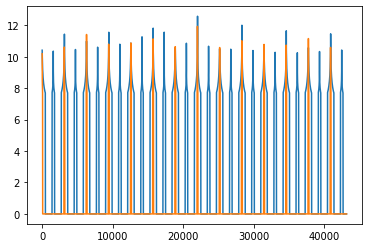

In [71]:
a = np.array([])
for t in range(bigsteps):
    a = np.append(a, data[t]['[1, 1]']['[2, 1]'])
b = np.array([])
for t in range(bigsteps):
    b = np.append(b, data[t]['[1, 1]']['[5, 1]'])
plt.plot([i for i in range(bigsteps)], a)
plt.plot([i for i in range(bigsteps)], b)

/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator


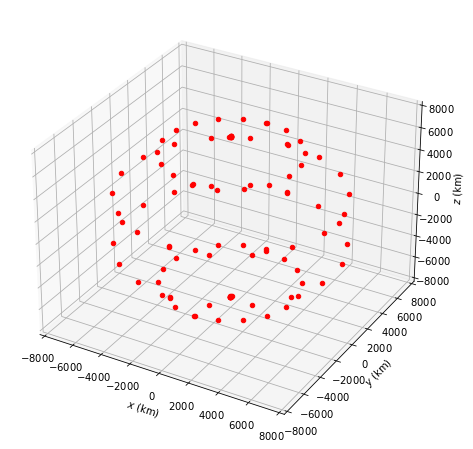

In [61]:
def plot_initial_configuration(S,R):

    # Last modified: 28 October 2019

    '''
    Plots the initial configuration of the ground stations and the satellites.
    R is the radius of the earth (in meters).
    '''

    fig=plt.figure(figsize=(8,8))


    ax=fig.add_subplot(111,projection='3d')       

    if S!=None:
        for i in list(S.keys()):#range(len(S)):
            for j in list(S[i].keys()):#range(len(S[i])-1):
                if j=='axis':
                    continue
                else:
                    ax.scatter(S[i][j][0],S[i][j][1],S[i][j][2],c='r')  

    ax.set_xlabel('$x$ (km)')
    ax.set_ylabel('$y$ (km)')
    ax.set_zlabel('$z$ (km)')

    ax.set_xlim(-8000000,8000000)
    ax.set_ylim(-8000000,8000000)
    ax.set_zlim(-8000000,8000000)

    ax.set_xticklabels(['$-8000$','$-6000$','$-4000$','$-2000$','$0$','$2000$','$4000$','$6000$','$8000$'])
    ax.set_yticklabels(['$-8000$','$-6000$','$-4000$','$-2000$','$0$','$2000$','$4000$','$6000$','$8000$'])
    ax.set_zticklabels(['$-8000$','$-6000$','$-4000$','$-2000$','$0$','$2000$','$4000$','$6000$','$8000$'])
     
    
    plt.show()
    
plot_initial_configuration(S_0,R)